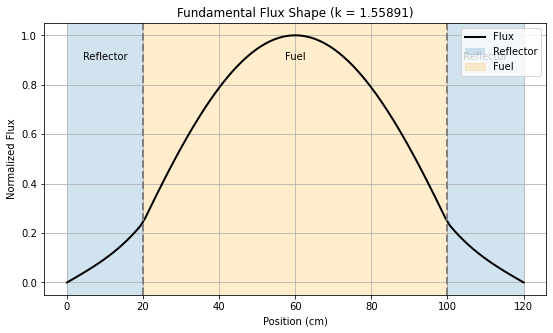

In [26]:
import numpy as np
import matplotlib.pyplot as plt

#1D Reactor heterogeneus monogroup (slab) Reflector-Fuel-Reflector
# ------------------
# Problem parameters

L= 120
N = 100
reflector = 20.0
fuel = 80.0
x = np.linspace(0, L, N)

D = np.zeros(N)
Sigma_a = np.zeros(N)
nuSigma_f = np.zeros(N)

fuel_region = (x >= reflector) & (x <= reflector + fuel)
reflector_region = ~fuel_region

# Fuel
D[fuel_region] = 1.2
Sigma_a[fuel_region] = 0.05
nuSigma_f[fuel_region] = 0.08

# Reflector
D[reflector_region] = 2.0
Sigma_a[reflector_region] = 0.01
nuSigma_f[reflector_region] = 0.0


# ------------------

def solve_reactor(L, D, Sigma_a, nuSigma_f, N):

    x = np.linspace(0, L, N)
    dx = x[1] - x[0]

    A = np.zeros((N, N))
    F = np.zeros((N, N))

    for i in range(1, N-1):

        D_left = 2*D[i]*D[i-1] / (D[i] + D[i-1])
        D_right = 2*D[i]*D[i+1] / (D[i] + D[i+1])

        A[i, i-1] = -D_left/dx**2
        A[i, i]   = (D_left + D_right)/dx**2 + Sigma_a[i]
        A[i, i+1] = -D_right/dx**2

        F[i, i] = nuSigma_f[i]

    # Boundary conditions
    A[0,0] = 1
    A[-1,-1] = 1

    # Eigenvalue problem
    M = np.linalg.inv(A) @ F

    eigvals, eigvecs = np.linalg.eig(M)

    idx = np.argmax(eigvals.real)

    k = eigvals[idx].real

    phi = eigvecs[:, idx].real

    if phi[N//2] < 0:
        phi = -phi

    phi /= np.max(phi)

    return x, phi, k

# ------------------

x, phi, k = solve_reactor(L, D,Sigma_a,nuSigma_f, N)

plt.figure(figsize=(9,5))

plt.plot(x, phi, color="black", linewidth=2, label="Flux")

# Region shading
plt.axvspan(0, reflector, alpha=0.2, label="Reflector")
plt.axvspan(reflector, reflector + fuel, alpha=0.2,color='orange', label="Fuel")
plt.axvspan(reflector + fuel, L, alpha=0.2)

# Interfaces
plt.axvline(reflector, color="gray", linestyle="--", linewidth=2)
plt.axvline(reflector + fuel, color="gray", linestyle="--", linewidth=2)

plt.text(10, 0.9, "Reflector", ha="center")
plt.text(60, 0.9, "Fuel", ha="center")
plt.text(110, 0.9, "Reflector", ha="center")

plt.xlabel("Position (cm)")
plt.ylabel("Normalized Flux")
plt.title(f"Fundamental Flux Shape (k = {k:.5f})")

plt.legend()
plt.grid(True)

plt.savefig("reflector_fuel_reflector_flux.png", dpi=300, bbox_inches="tight")

plt.show()

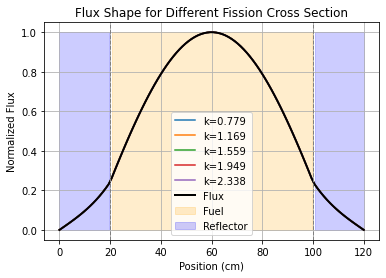

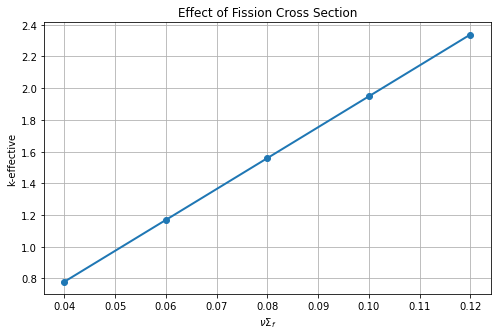

In [15]:
#Variacion de nuSigmaf

nuSigma_f_values = [0.04,0.06,0.08,0.10,0.12]

k_values = []

for nuSigma_f_fuel in nuSigma_f_values:   # nuSigma_f_fuel toma un valor distinto en cada vuelta: 0.04, luego 0.06, etc.
    
    nuSigma_f = np.zeros_like(x)              # array de 100 ceros (mismo tamaño que x)
    nuSigma_f[fuel_region] = nuSigma_f_fuel   # pone ESE valor escalar en las 66 posiciones del fuel
    
    x, phi, k = solve_reactor(L, D, Sigma_a, nuSigma_f, N)
    k_values.append(k)
    plt.plot(x,phi,label=f"k={k:.3f}")
    

plt.plot(x, phi, color='black', linewidth=2, label="Flux")

# Sombreado de zonas
plt.fill_between(x, phi.min(), phi.max(), where=fuel_region, 
                  color='orange', alpha=0.2, label="Fuel")
plt.fill_between(x, phi.min(), phi.max(), where=reflector_region, 
                  color='blue', alpha=0.2, label="Reflector")

# Líneas divisorias entre fuel y reflector
plt.axvline(x=reflector, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=reflector + fuel, color='gray', linestyle='--', linewidth=1)

plt.xlabel("Position (cm)")
plt.ylabel("Normalized Flux")
plt.title("Flux Shape for Different Fission Cross Section")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(nuSigma_f_values,k_values,"o-",linewidth=2)

plt.xlabel(r"$\nu\Sigma_f$")
plt.ylabel("k-effective")
plt.title("Effect of Fission Cross Section")

plt.grid(True)

plt.show()

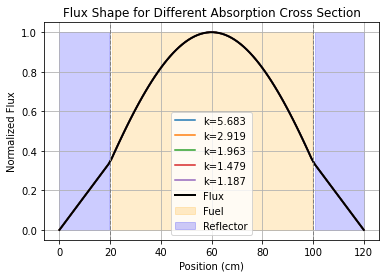

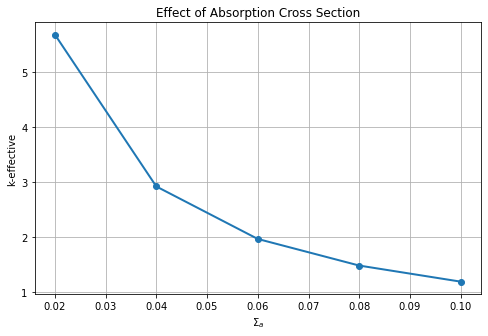

In [16]:
#Variacion de Sigmaabs
Sigma_a_values = [0.02,0.04,0.06,0.08,0.10]

k_values = []

for Sigma_a_fuel in Sigma_a_values:   # nuSigma_f_fuel toma un valor distinto en cada vuelta: 0.04, luego 0.06, etc.
    
    Sigma_a = np.zeros_like(x)              # array de 100 ceros (mismo tamaño que x)
    Sigma_a[fuel_region] = Sigma_a_fuel   # pone ESE valor escalar en las 66 posiciones del fuel
    
    x, phi, k = solve_reactor(L, D, Sigma_a, nuSigma_f, N)
    k_values.append(k)
    plt.plot(x,phi,label=f"k={k:.3f}")
    

plt.plot(x, phi, color='black', linewidth=2, label="Flux")

# Sombreado de zonas
plt.fill_between(x, phi.min(), phi.max(), where=fuel_region, 
                  color='orange', alpha=0.2, label="Fuel")
plt.fill_between(x, phi.min(), phi.max(), where=reflector_region, 
                  color='blue', alpha=0.2, label="Reflector")

# Líneas divisorias entre fuel y reflector
plt.axvline(x=reflector, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=reflector + fuel, color='gray', linestyle='--', linewidth=1)

plt.xlabel("Position (cm)")
plt.ylabel("Normalized Flux")
plt.title("Flux Shape for Different Absorption Cross Section")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(Sigma_a_values,k_values,"o-",linewidth=2)

plt.xlabel(r"$\Sigma_a$")
plt.ylabel("k-effective")
plt.title("Effect of Absorption Cross Section")

plt.grid(True)

plt.show()

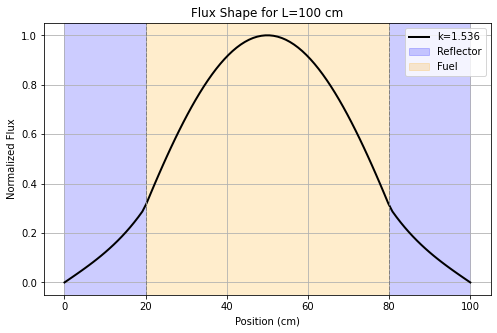

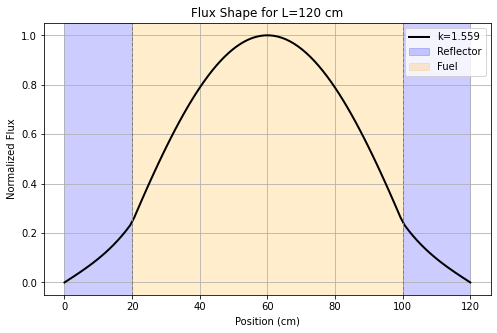

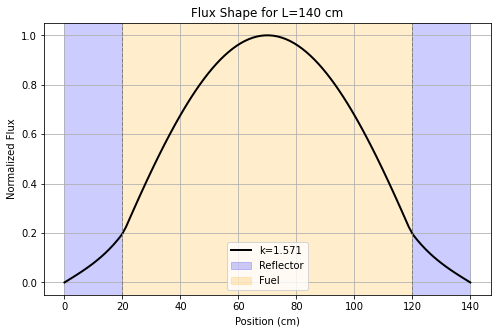

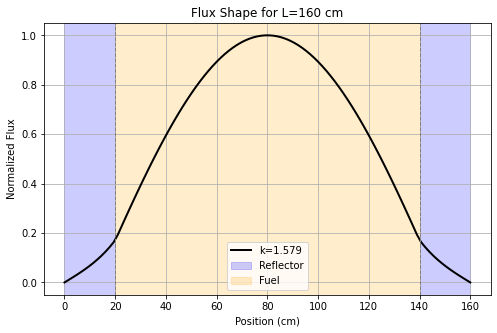

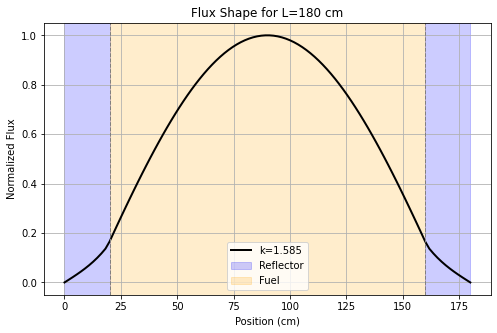

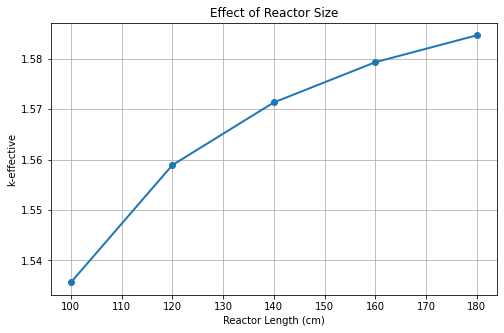

In [23]:
lengths = [100, 120, 140, 160, 180]  
k_values = []

for L in lengths:
    x = np.linspace(0, L, N)
    
    # Definir regiones según geometría Reflector-Fuel-Reflector
    fuel_region = (x >= reflector) & (x <= L - reflector)
    reflector_region = ~fuel_region
    
    D = np.zeros(N)
    Sigma_a = np.zeros(N)
    nuSigma_f = np.zeros(N)
    
    # Fuel
    D[fuel_region] = 1.2
    Sigma_a[fuel_region] = 0.05
    nuSigma_f[fuel_region] = 0.08
    
    # Reflector
    D[reflector_region] = 2.0
    Sigma_a[reflector_region] = 0.01
    nuSigma_f[reflector_region] = 0.0
    
    x, phi, k = solve_reactor(L, D, Sigma_a, nuSigma_f, N)
    k_values.append(k)
    
    plt.figure(figsize=(8,5))
    plt.plot(x, phi, color='black', linewidth=2, label=f"k={k:.3f}")
    
    # Sombreado de zonas (3 tramos: reflector-fuel-reflector)
    plt.axvspan(0, reflector, color='blue', alpha=0.2, label="Reflector")
    plt.axvspan(reflector, L - reflector, color='orange', alpha=0.2, label="Fuel")
    plt.axvspan(L - reflector, L, color='blue', alpha=0.2)
    
    # Líneas divisorias
    plt.axvline(x=reflector, color='gray', linestyle='--', linewidth=1)
    plt.axvline(x=L - reflector, color='gray', linestyle='--', linewidth=1)
    
    plt.xlabel("Position (cm)")
    plt.ylabel("Normalized Flux")
    plt.title(f"Flux Shape for L={L} cm")
    plt.legend()
    plt.grid(True)
    plt.show()

plt.figure(figsize=(8,5))
plt.plot(lengths, k_values, "o-", linewidth=2)
plt.xlabel("Reactor Length (cm)")
plt.ylabel("k-effective")
plt.title("Effect of Reactor Size")
plt.grid(True)
plt.show()
